In [52]:
import os
import numpy as np
import pandas as pd
import gudhi.wasserstein as gw

In [53]:
ruta = "/home/jupyter-luisraul/tda-cell-patterns-workshop/codigos/resultados/"

In [54]:
archivos = sorted(
    [f for f in os.listdir(ruta) if f.endswith(".csv")]
)

print("Archivos encontrados:")

for i, archivo in enumerate(archivos):
    print(f"{i}: {archivo}")

Archivos encontrados:
0: high_grade_displasia_FAAGSCC_13_HGD_15_diag.csv
1: high_grade_displasia_FAAGSCC_13_HGD_2_diag.csv
2: high_grade_displasia_FAAGSCC_13_HGD_7_diag.csv
3: invasive_carcinoma_AGSCC_1_IC_18_diag.csv
4: invasive_carcinoma_AGSCC_1_IC_24_diag.csv
5: invasive_carcinoma_AGSCC_1_IC_28_diag.csv
6: light_grade_displasia_F82P1_LGD_5_diag.csv
7: light_grade_displasia_F82P1_LGD_6_diag.csv
8: stroma_ad_high_grade_displasia_FAAGSCC_13_HGD_4_diag.csv
9: stroma_ad_high_grade_displasia_FAAGSCC_13_HGD_7_diag.csv
10: stroma_ad_invasive_carcinoma_AGSCC_1_IC_111_diag.csv
11: stroma_ad_invasive_carcinoma_AGSCC_1_IC_99_diag.csv
12: stroma_ad_light_grade_displasia_F33P1_LGD_7_diag.csv
13: stroma_ad_light_grade_displasia_F81P1_LGD_1_diag.csv


In [55]:
diag_dim0 = []
diag_dim1 = []

for archivo in archivos:

    df = pd.read_csv(os.path.join(ruta, archivo))

    d0 = (
    df[
        (df["dimension"] == 0)
        & (np.isfinite(df["death"]))
    ][["birth", "death"]]
    .to_numpy()
    )

    d1 = (
        df[
            (df["dimension"] == 1)
            & (np.isfinite(df["death"]))
        ][["birth", "death"]]
        .to_numpy()
    )

    diag_dim0.append(d0)
    diag_dim1.append(d1)

In [44]:
n = len(archivos)

dist_dim0 = np.zeros((n, n))
dist_dim1 = np.zeros((n, n))

In [45]:
for i in range(n):

    for j in range(n):

        dist_dim0[i, j] = gw.wasserstein_distance(
            diag_dim0[i],
            diag_dim0[j],
            order=1
        )

        dist_dim1[i, j] = gw.wasserstein_distance(
            diag_dim1[i],
            diag_dim1[j],
            order=1
        )

        # Alternativa:
        # dist_dim0[i, j] = gd.bottleneck_distance(
        #     diag_dim0[i],
        #     diag_dim0[j]
        # )

In [46]:
df_dist0 = pd.DataFrame(
    dist_dim0,
    index=archivos,
    columns=archivos
)

df_dist1 = pd.DataFrame(
    dist_dim1,
    index=archivos,
    columns=archivos
)

print(df_dist0)
print(df_dist1)

                                                    high_grade_displasia_FAAGSCC_13_HGD_15_diag.csv  \
high_grade_displasia_FAAGSCC_13_HGD_15_diag.csv                                            0.000000   
high_grade_displasia_FAAGSCC_13_HGD_2_diag.csv                                          8198.221181   
high_grade_displasia_FAAGSCC_13_HGD_7_diag.csv                                          7072.017586   
invasive_carcinoma_AGSCC_1_IC_18_diag.csv                                               5110.855775   
invasive_carcinoma_AGSCC_1_IC_24_diag.csv                                               2802.038489   
invasive_carcinoma_AGSCC_1_IC_28_diag.csv                                               3567.285599   
light_grade_displasia_F82P1_LGD_5_diag.csv                                             11877.053258   
light_grade_displasia_F82P1_LGD_6_diag.csv                                              9874.348975   
stroma_ad_high_grade_displasia_FAAGSCC_13_HGD_4...                       

In [47]:
df_dist0.to_csv(
    os.path.join(ruta, "wasserstein_dim0.csv")
)

df_dist1.to_csv(
    os.path.join(ruta, "wasserstein_dim1.csv")
)

print("Matrices guardadas.")

Matrices guardadas.


In [48]:
import os
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Ruta de las matrices de distancia
ruta = "/home/jupyter-luisraul/tda-cell-patterns-workshop/codigos/resultados/distancias"

# Carpeta de salida
salida = os.path.join(ruta, "visualizacion")
os.makedirs(salida, exist_ok=True)

In [49]:
def roi(nombre):

    nombre = nombre.lower()

    if "invasive_carcinoma" in nombre:
        return "IC"

    elif "high_grade_displasia" in nombre:
        return "HGD"

    elif "light_grade_displasia" in nombre:
        return "LGD"

    return "Other"


def fanconi(nombre):

    nombre = nombre.upper()

    if re.search(r"_FA", nombre):
        return "Fanconi"

    if re.search(r"_F\d", nombre):
        return "Fanconi"

    return "No Fanconi"


def tejido(nombre):

    if nombre.startswith("stroma_ad_"):
        return "Stroma"

    return "Epithelium"

In [50]:
roi_colors = {
    "IC": "#b30000",
    "HGD": "#2166ac",
    "LGD": "#ffd700",
    "Other": "#aaaaaa"
}

fanconi_colors = {
    "Fanconi": "#762a83",
    "No Fanconi": "#1b7837"
}

tejido_colors = {
    "Stroma": "#ff7f00",
    "Epithelium": "#4d4d4d"
}

Procesando: wasserstein_dim0.csv


/opt/conda/envs/TDA/lib/python3.7/site-packages/seaborn/matrix.py:531: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  metric=self.metric)


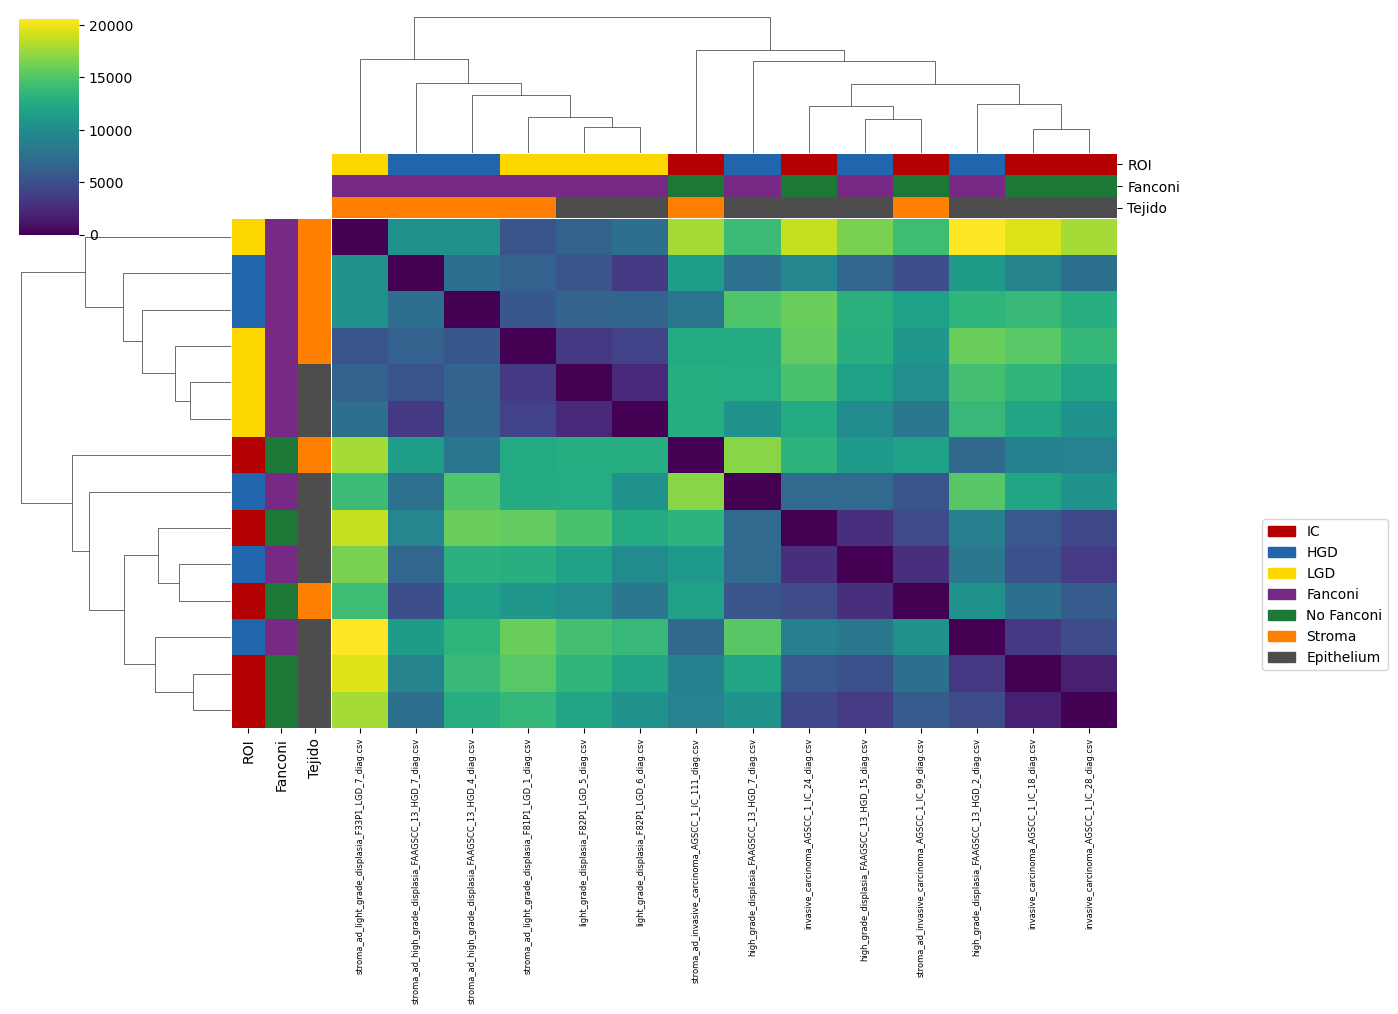

Procesando: wasserstein_dim1.csv


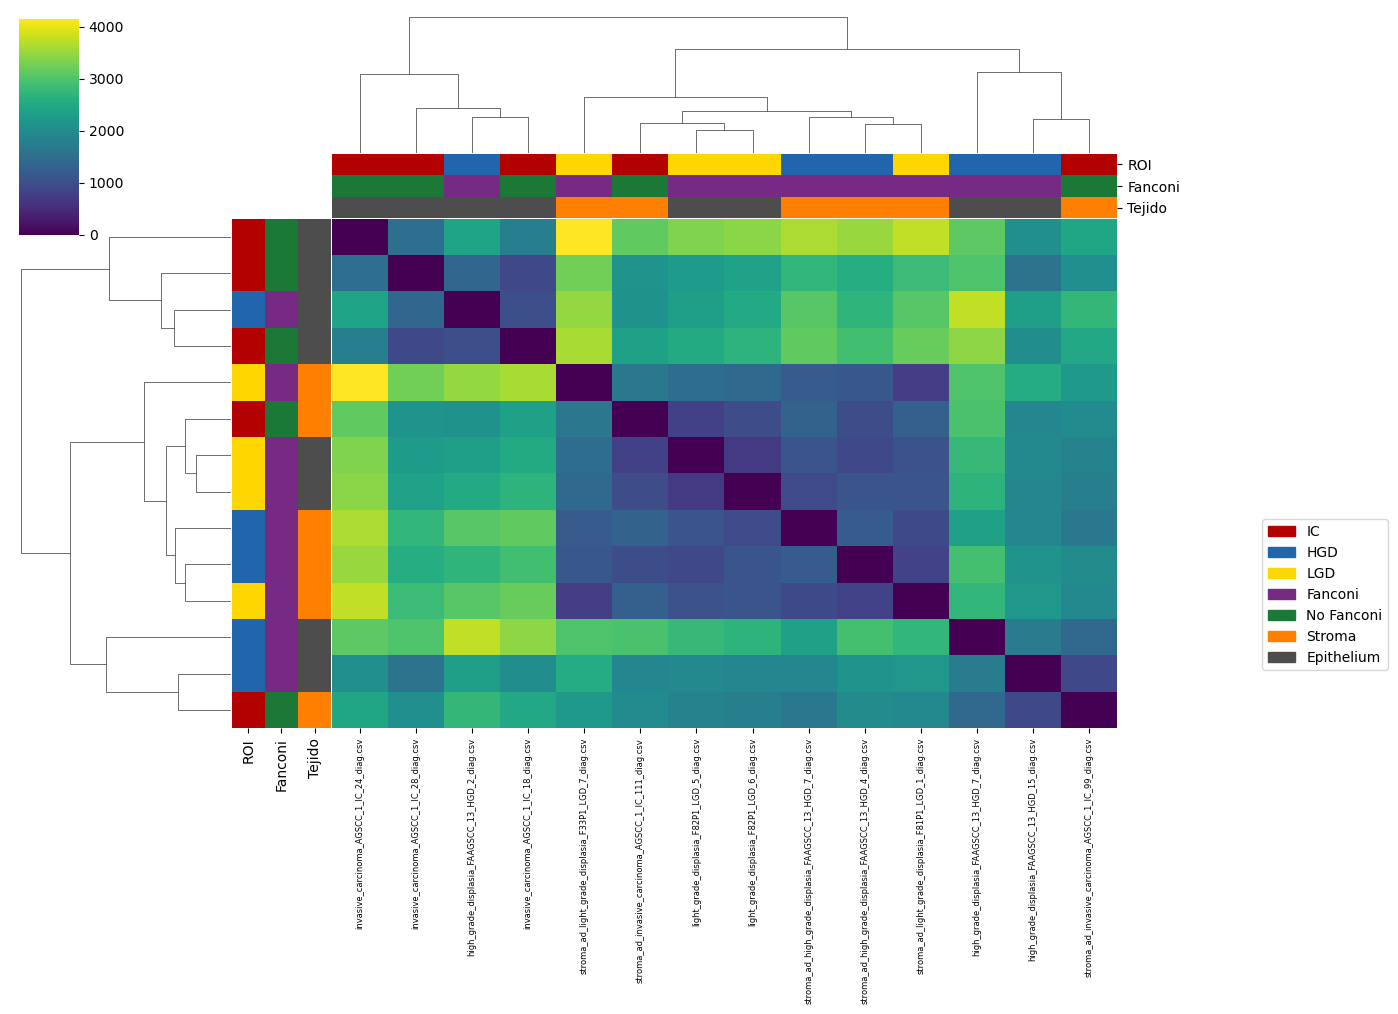

In [51]:
archivos = [
    f for f in os.listdir(ruta)
    if f.endswith(".csv")
]

for archivo in archivos:

    print("Procesando:", archivo)

    df = pd.read_csv(
        os.path.join(ruta, archivo),
        index_col=0
    )

    muestras = df.index.tolist()

    colores = pd.DataFrame({
        "ROI": [roi_colors[roi(x)] for x in muestras],
        "Fanconi": [fanconi_colors[fanconi(x)] for x in muestras],
        "Tejido": [tejido_colors[tejido(x)] for x in muestras]
    }, index=muestras)

    g = sns.clustermap(
        df,
        cmap="viridis",
        method="average",
        row_colors=colores,
        col_colors=colores,
        figsize=(12,12),
        yticklabels=False
    )

    plt.setp(
        g.ax_heatmap.get_xticklabels(),
        rotation=90,
        fontsize=6
    )

    g.fig.legend(
        handles=[
            Patch(color="#b30000", label="IC"),
            Patch(color="#2166ac", label="HGD"),
            Patch(color="#ffd700", label="LGD"),
            Patch(color="#762a83", label="Fanconi"),
            Patch(color="#1b7837", label="No Fanconi"),
            Patch(color="#ff7f00", label="Stroma"),
            Patch(color="#4d4d4d", label="Epithelium")
        ],
        bbox_to_anchor=(1.05, 0.5),
        loc="center left"
    )

    nombre = os.path.splitext(archivo)[0]

    plt.savefig(
        os.path.join(
            salida,
            f"clustermap_{nombre}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()